## Graph Construction Plan

### Reference grid
The graph will be constructed on the `Burn_Prob.img` grid, since this raster is the primary prediction target. This ensures that every graph node corresponds directly to a target cell.

### Alignment strategy
All feature rasters will be aligned to the target grid before graph creation.

- Continuous rasters use bilinear resampling:
  - CFL
  - FSP_Index
  - Ignition_Prob
  - Struct_Exp_Index

- Categorical rasters use nearest-neighbor resampling:
  - Fuel_Models

### Node definition
Each valid raster cell on the aligned target grid becomes one node.

### Node features
Each node feature vector includes:
- CFL
- FSP_Index
- Fuel_Models
- Ignition_Prob
- Struct_Exp_Index
- normalized row/column coordinates

### Target
Each node target is the burn probability at the same aligned target-grid cell.

### Edges
Edges are created using 8-neighbor spatial connectivity to reflect local wildfire spread interactions.

### Output
The final result is a PyTorch Geometric `Data` object containing:
- node feature matrix `x`
- target vector `y`
- graph edges `edge_index`
- node positions `pos`

In [1]:
import os
os.chdir("..")

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.append("src")

import torch
import numpy as np
import matplotlib.pyplot as plt

from wildfire_gnn.evaluation.graph_checks import (
    tensor_basic_stats,
    count_non_finite,
    edge_density,
    unique_categorical_values,
)


In [2]:
graph_path = "data/processed/graph_data.pt"
data = torch.load(graph_path, weights_only=False)

data

Data(x=[300000, 7], edge_index=[2, 991684], y=[300000, 1], pos=[300000, 2], num_nodes_original_grid=3589100, num_valid_nodes_before_sampling=702972, num_valid_nodes=300000, reference_height=1900, reference_width=1889, target_name='Burn_Prob.img', feature_names=[7])

In [3]:
print("Graph loaded successfully")
print(f"x shape: {tuple(data.x.shape)}")
print(f"y shape: {tuple(data.y.shape)}")
print(f"edge_index shape: {tuple(data.edge_index.shape)}")
print(f"pos shape: {tuple(data.pos.shape)}")
print(f"num_valid_nodes: {data.num_valid_nodes}")
print(f"num_valid_nodes_before_sampling: {data.num_valid_nodes_before_sampling}")
print(f"reference grid: ({data.reference_height}, {data.reference_width})")
print(f"target name: {data.target_name}")
print(f"feature names: {data.feature_names}")

Graph loaded successfully
x shape: (300000, 7)
y shape: (300000, 1)
edge_index shape: (2, 991684)
pos shape: (300000, 2)
num_valid_nodes: 300000
num_valid_nodes_before_sampling: 702972
reference grid: (1900, 1889)
target name: Burn_Prob.img
feature names: ['CFL.img', 'FSP_Index.img', 'Ignition_Prob.img', 'Struct_Exp_Index.img', 'Fuel_Models.img', 'row_norm', 'col_norm']


In [4]:
x_stats = tensor_basic_stats(data.x)
x_non_finite = count_non_finite(data.x)

print("X stats:", x_stats)
print("X non-finite counts:", x_non_finite)

X stats: {'shape': (300000, 7), 'min': -30.038822174072266, 'max': 189.0, 'mean': 19.731983184814453, 'std': 49.261695861816406}
X non-finite counts: {'nan_count': 0, 'posinf_count': 0, 'neginf_count': 0}


In [5]:
y_stats = tensor_basic_stats(data.y)
y_non_finite = count_non_finite(data.y)

print("Y stats:", y_stats)
print("Y non-finite counts:", y_non_finite)

Y stats: {'shape': (300000, 1), 'min': 2.3405966203426942e-05, 'max': 0.24930262565612793, 'mean': 0.02515261061489582, 'std': 0.03347635269165039}
Y non-finite counts: {'nan_count': 0, 'posinf_count': 0, 'neginf_count': 0}


In [6]:
num_nodes = int(data.x.shape[0])
num_edges = int(data.edge_index.shape[1])

print(f"Number of nodes: {num_nodes}")
print(f"Number of directed edges: {num_edges}")
print(f"Average directed edges per node: {edge_density(num_nodes, num_edges):.4f}")

Number of nodes: 300000
Number of directed edges: 991684
Average directed edges per node: 3.3056


In [7]:
pos_stats = tensor_basic_stats(data.pos)
print("Position stats:", pos_stats)

Position stats: {'shape': (300000, 2), 'min': 3.0, 'max': 1897.0, 'mean': 745.03848, 'std': 416.5259795850549}


In [8]:
for idx, feature_name in enumerate(data.feature_names):
    col = data.x[:, idx]
    stats = tensor_basic_stats(col)
    non_finite = count_non_finite(col)

    print(f"\nFeature: {feature_name}")
    print(stats)
    print(non_finite)


Feature: CFL.img
{'shape': (300000,), 'min': -11.1829195022583, 'max': 0.1678120195865631, 'mean': 3.9672851670502496e-09, 'std': 1.0}
{'nan_count': 0, 'posinf_count': 0, 'neginf_count': 0}

Feature: FSP_Index.img
{'shape': (300000,), 'min': -30.038822174072266, 'max': 0.07234921306371689, 'mean': 2.2125243859250077e-09, 'std': 1.0000001192092896}
{'nan_count': 0, 'posinf_count': 0, 'neginf_count': 0}

Feature: Ignition_Prob.img
{'shape': (300000,), 'min': -18.30590057373047, 'max': 0.0964806005358696, 'mean': -9.663899902534467e-09, 'std': 1.0}
{'nan_count': 0, 'posinf_count': 0, 'neginf_count': 0}

Feature: Struct_Exp_Index.img
{'shape': (300000,), 'min': -30.038822174072266, 'max': 0.07234921306371689, 'mean': 2.2125243859250077e-09, 'std': 1.0000001192092896}
{'nan_count': 0, 'posinf_count': 0, 'neginf_count': 0}

Feature: Fuel_Models.img
{'shape': (300000,), 'min': 91.0, 'max': 189.0, 'mean': 137.33702087402344, 'std': 29.096410751342773}
{'nan_count': 0, 'posinf_count': 0, 'negi

In [9]:
fuel_idx = data.feature_names.index("Fuel_Models.img")
fuel_col = data.x[:, fuel_idx]

fuel_info = unique_categorical_values(fuel_col)
fuel_info

{'num_unique': 24,
 'sample_values': [91.0,
  93.0,
  98.0,
  99.0,
  101.0,
  102.0,
  104.0,
  121.0,
  122.0,
  123.0,
  141.0,
  142.0,
  145.0,
  147.0,
  161.0,
  164.0,
  165.0,
  181.0,
  182.0,
  183.0],
 'sample_counts': [5888,
  308,
  359,
  438,
  44633,
  6037,
  10566,
  66483,
  12176,
  1082,
  4230,
  47,
  49437,
  11213,
  20448,
  4713,
  16699,
  97,
  697,
  267]}

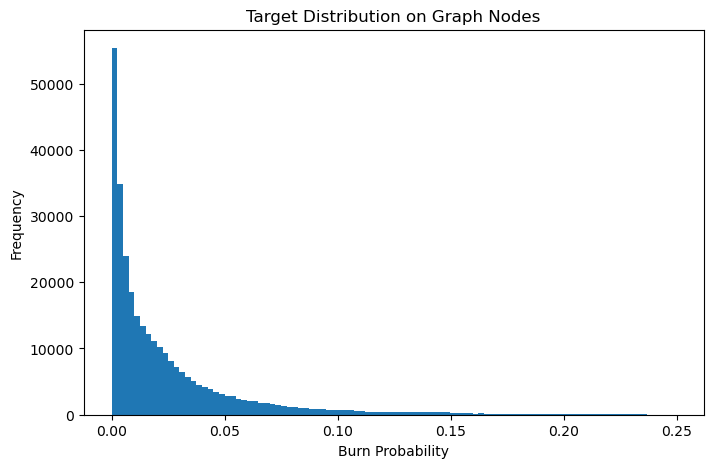

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(data.y.cpu().numpy().reshape(-1), bins=100)
plt.title("Target Distribution on Graph Nodes")
plt.xlabel("Burn Probability")
plt.ylabel("Frequency")
plt.show()

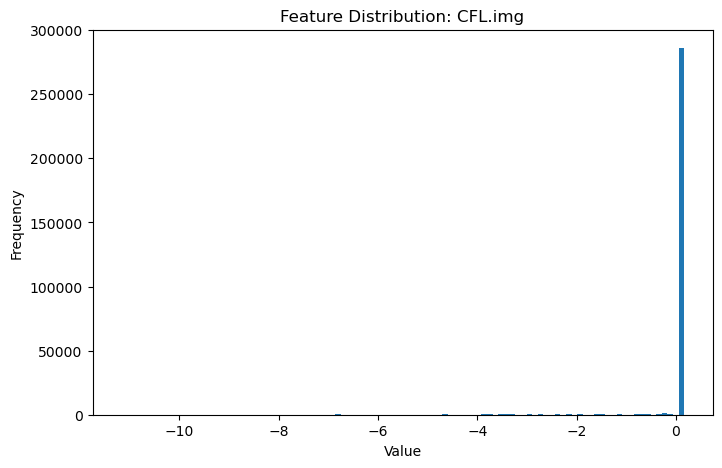

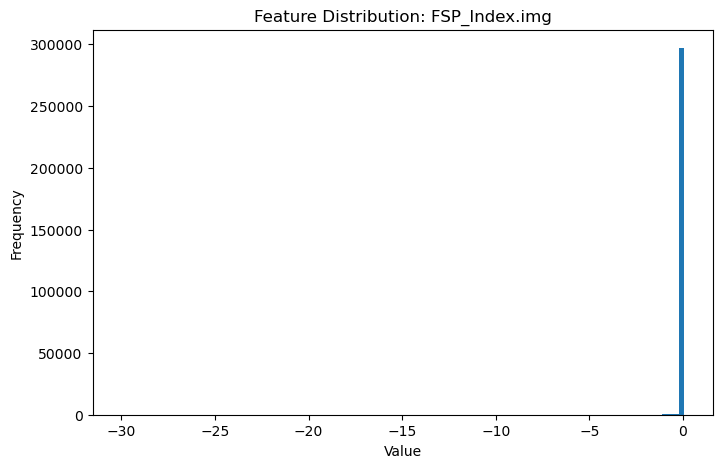

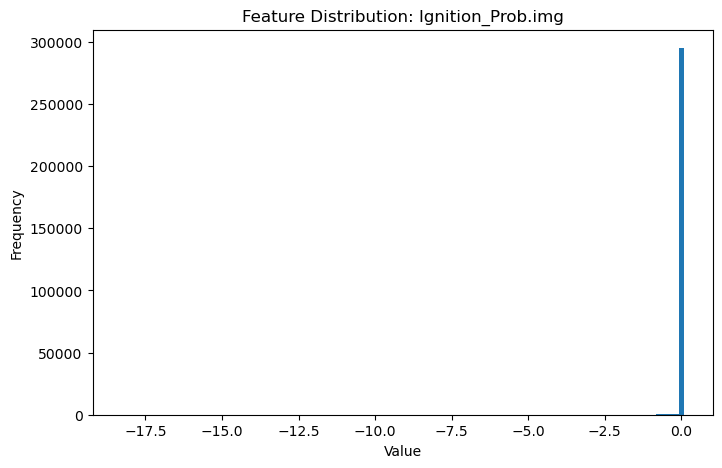

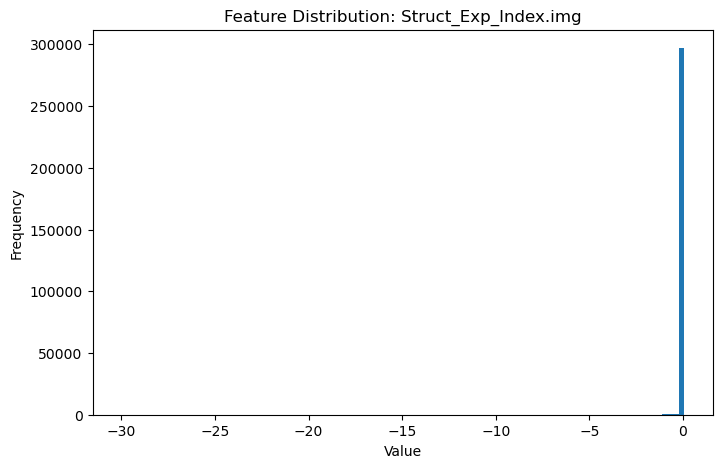

In [11]:
continuous_feature_names = [
    "CFL.img",
    "FSP_Index.img",
    "Ignition_Prob.img",
    "Struct_Exp_Index.img",
]

for feature_name in continuous_feature_names:
    idx = data.feature_names.index(feature_name)
    values = data.x[:, idx].cpu().numpy()

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=100)
    plt.title(f"Feature Distribution: {feature_name}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

In [12]:
row_idx = data.feature_names.index("row_norm")
col_idx = data.feature_names.index("col_norm")

row_stats = tensor_basic_stats(data.x[:, row_idx])
col_stats = tensor_basic_stats(data.x[:, col_idx])

print("row_norm stats:", row_stats)
print("col_norm stats:", col_stats)

row_norm stats: {'shape': (300000,), 'min': 0.0015797788510099053, 'max': 0.9989467859268188, 'mean': 0.4103807508945465, 'std': 0.24578286707401276}
col_norm stats: {'shape': (300000,), 'min': 0.0015889829955995083, 'max': 0.9984109997749329, 'mean': 0.37646394968032837, 'std': 0.1885998249053955}


In [13]:
edge_sample = data.edge_index[:, :10]
edge_sample

tensor([[294917, 294917, 250220, 250220,  15818,  15818,  15818,  15818,  18175,
          18175],
        [ 15818, 250220, 294917,  15818, 294917,  21418, 250220, 232657, 174573,
         126374]])

In [14]:
assert data.x.shape[0] == data.y.shape[0] == data.pos.shape[0], "Mismatch in node-aligned tensors"
assert data.edge_index.shape[0] == 2, "edge_index must have shape [2, num_edges]"

print("All core graph shape checks passed.")

All core graph shape checks passed.


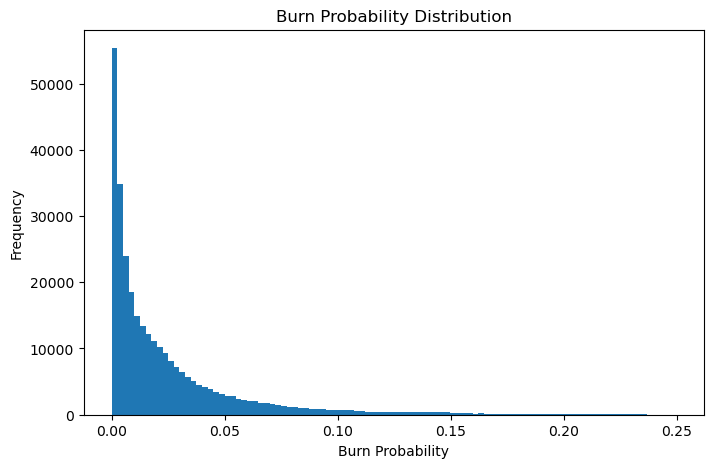

In [16]:

os.makedirs("reports/figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.hist(data.y.cpu().numpy().reshape(-1), bins=100)
plt.title("Burn Probability Distribution")
plt.xlabel("Burn Probability")
plt.ylabel("Frequency")

plt.savefig("reports/figures/burn_probability_histogram.png", dpi=300)
plt.show()

In [17]:
for idx, feature_name in enumerate(data.feature_names[:4]): 
    col = data.x[:, idx].cpu().numpy()

    plt.figure(figsize=(6, 4))
    plt.hist(col, bins=100)
    plt.title(f"Feature Distribution: {feature_name}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    filename = f"reports/figures/feature_{feature_name}.png"
    plt.savefig(filename, dpi=300)
    plt.close()

In [18]:
import pandas as pd

stats_list = []

for idx, feature_name in enumerate(data.feature_names):
    col = data.x[:, idx].cpu().numpy()
    stats_list.append({
        "feature": feature_name,
        "min": col.min(),
        "max": col.max(),
        "mean": col.mean(),
        "std": col.std()
    })

df = pd.DataFrame(stats_list)
df.to_csv("reports/tables/feature_statistics.csv", index=False)

#  Graph Construction & Validation Summary

## 1. Graph Overview

We successfully constructed a graph representation of the wildfire dataset using aligned geospatial raster features.

### Graph Statistics:

* Number of nodes: **300,000 (subsampled)**
* Original valid nodes: **702,972**
* Number of edges: **991,684 (directed)**
* Average edges per node: **3.3056**

### Tensor Shapes:

* Node features (`X`): (300000, 7)
* Targets (`Y`): (300000, 1)
* Edge index: (2, 991684)
* Node positions (`pos`): (300000, 2)

### Feature Names:

* CFL.img
* FSP_Index.img
* Ignition_Prob.img
* Struct_Exp_Index.img
* Fuel_Models.img
* row_norm
* col_norm


## 2. Feature Validation

### Continuous Features (Normalized)

All continuous features were standardized using z-score normalization:

[
x' = \frac{x - \mu}{\sigma}
]

Observed statistics:

* Mean ≈ 0
* Std ≈ 1
* No NaN or infinite values

### Important Observation:

All continuous feature distributions appear visually similar after normalization.

#### Reason:

* Original data is highly skewed
* Most values are near zero
* Standardization compresses distributions

#### Interpretation:

This reflects real-world wildfire dynamics:

* Majority of regions have low fire risk
* High-risk areas are sparse


## 3. Categorical Feature

### Fuel Models:

* Number of unique categories: **24**
* Value range: 91 → 189
* No missing or invalid values

This feature represents discrete fuel types and will be treated differently during modeling.


## 4. Target Variable Analysis

### Burn Probability Distribution:

* Min: ~0.000023
* Max: ~0.249
* Mean: ~0.025

### Observation:

* Highly skewed toward low values
* Long tail of high-risk regions

#### Implication:

* Regression is imbalanced
* Rare extreme events are critical


## 5. Graph Structure Validation

### All checks passed:

* Node alignment:
  ✔ X, Y, pos have same number of nodes

* Edge structure:
  ✔ edge_index shape = (2, num_edges)

* No NaN / Inf values:
  ✔ Clean dataset

---

## 6. Spatial Information

Position statistics:

* Grid size: (1900, 1889)
* row_norm, col_norm in [0, 1]

These encode spatial structure directly into the graph.

---

## 7. Key Findings

1. Graph construction is successful and stable
2. Dataset is clean (no invalid values)
3. Continuous features are heavily skewed
4. Target variable is imbalanced
5. Spatial information is preserved
6. Graph sparsity is appropriate for GNN training

---

## 8. Conclusion

The graph is ready for:

* Baseline models
* GNN training
* Uncertainty modeling

This represents a **valid and research-grade graph representation** of wildfire dynamics.
